In [1]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import scienceplots

/home/nlonyuk/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
df = pd.read_csv('../../cp/results_base3_tops.csv')
df

,config,num_trains,num_expansions,cost,makespan_pp
0,10,3,6101,53,84
1,10,4,7296,81,105
2,10,5,6881,104,144
3,10,6,6191,138,157
4,10,7,3534,171,189
...,...,...,...,...,...
65,50,4,6198,28,115
66,50,5,4476,53,182
67,50,6,1596,56,196
68,51,3,87558,21,101


In [3]:
df_tfd = pd.read_csv('../../cp/results_base1_tfd.csv')
df_tfd

,Unnamed: 0.6,config,num_trains,num_expansions,makespan,makespan_pp,search_time,Unnamed: 0.5,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0
0,0,19.0,3.0,6211.0,135.0,90.0,270.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,19.0,4.0,3983.0,186.0,136.0,260.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2,19.0,5.0,1727.0,286.0,147.0,240.0,NaN,NaN,NaN,NaN,NaN,NaN
3,3,19.0,6.0,1144.0,331.0,201.0,210.0,NaN,NaN,NaN,NaN,NaN,NaN
4,4,17.0,3.0,199571.0,108.0,116.0,290.0,0.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,99,9.0,7.0,4389.0,377.0,239.0,21.0,95.0,84.0,41.0,29.0,NaN,NaN
100,100,9.0,8.0,1051.0,536.0,379.0,10.0,96.0,85.0,42.0,30.0,NaN,NaN
101,101,9.0,9.0,6839.0,563.0,427.0,110.0,97.0,86.0,43.0,31.0,NaN,NaN
102,102,9.0,10.0,4719.0,624.0,462.0,90.0,98.0,87.0,44.0,32.0,NaN,NaN


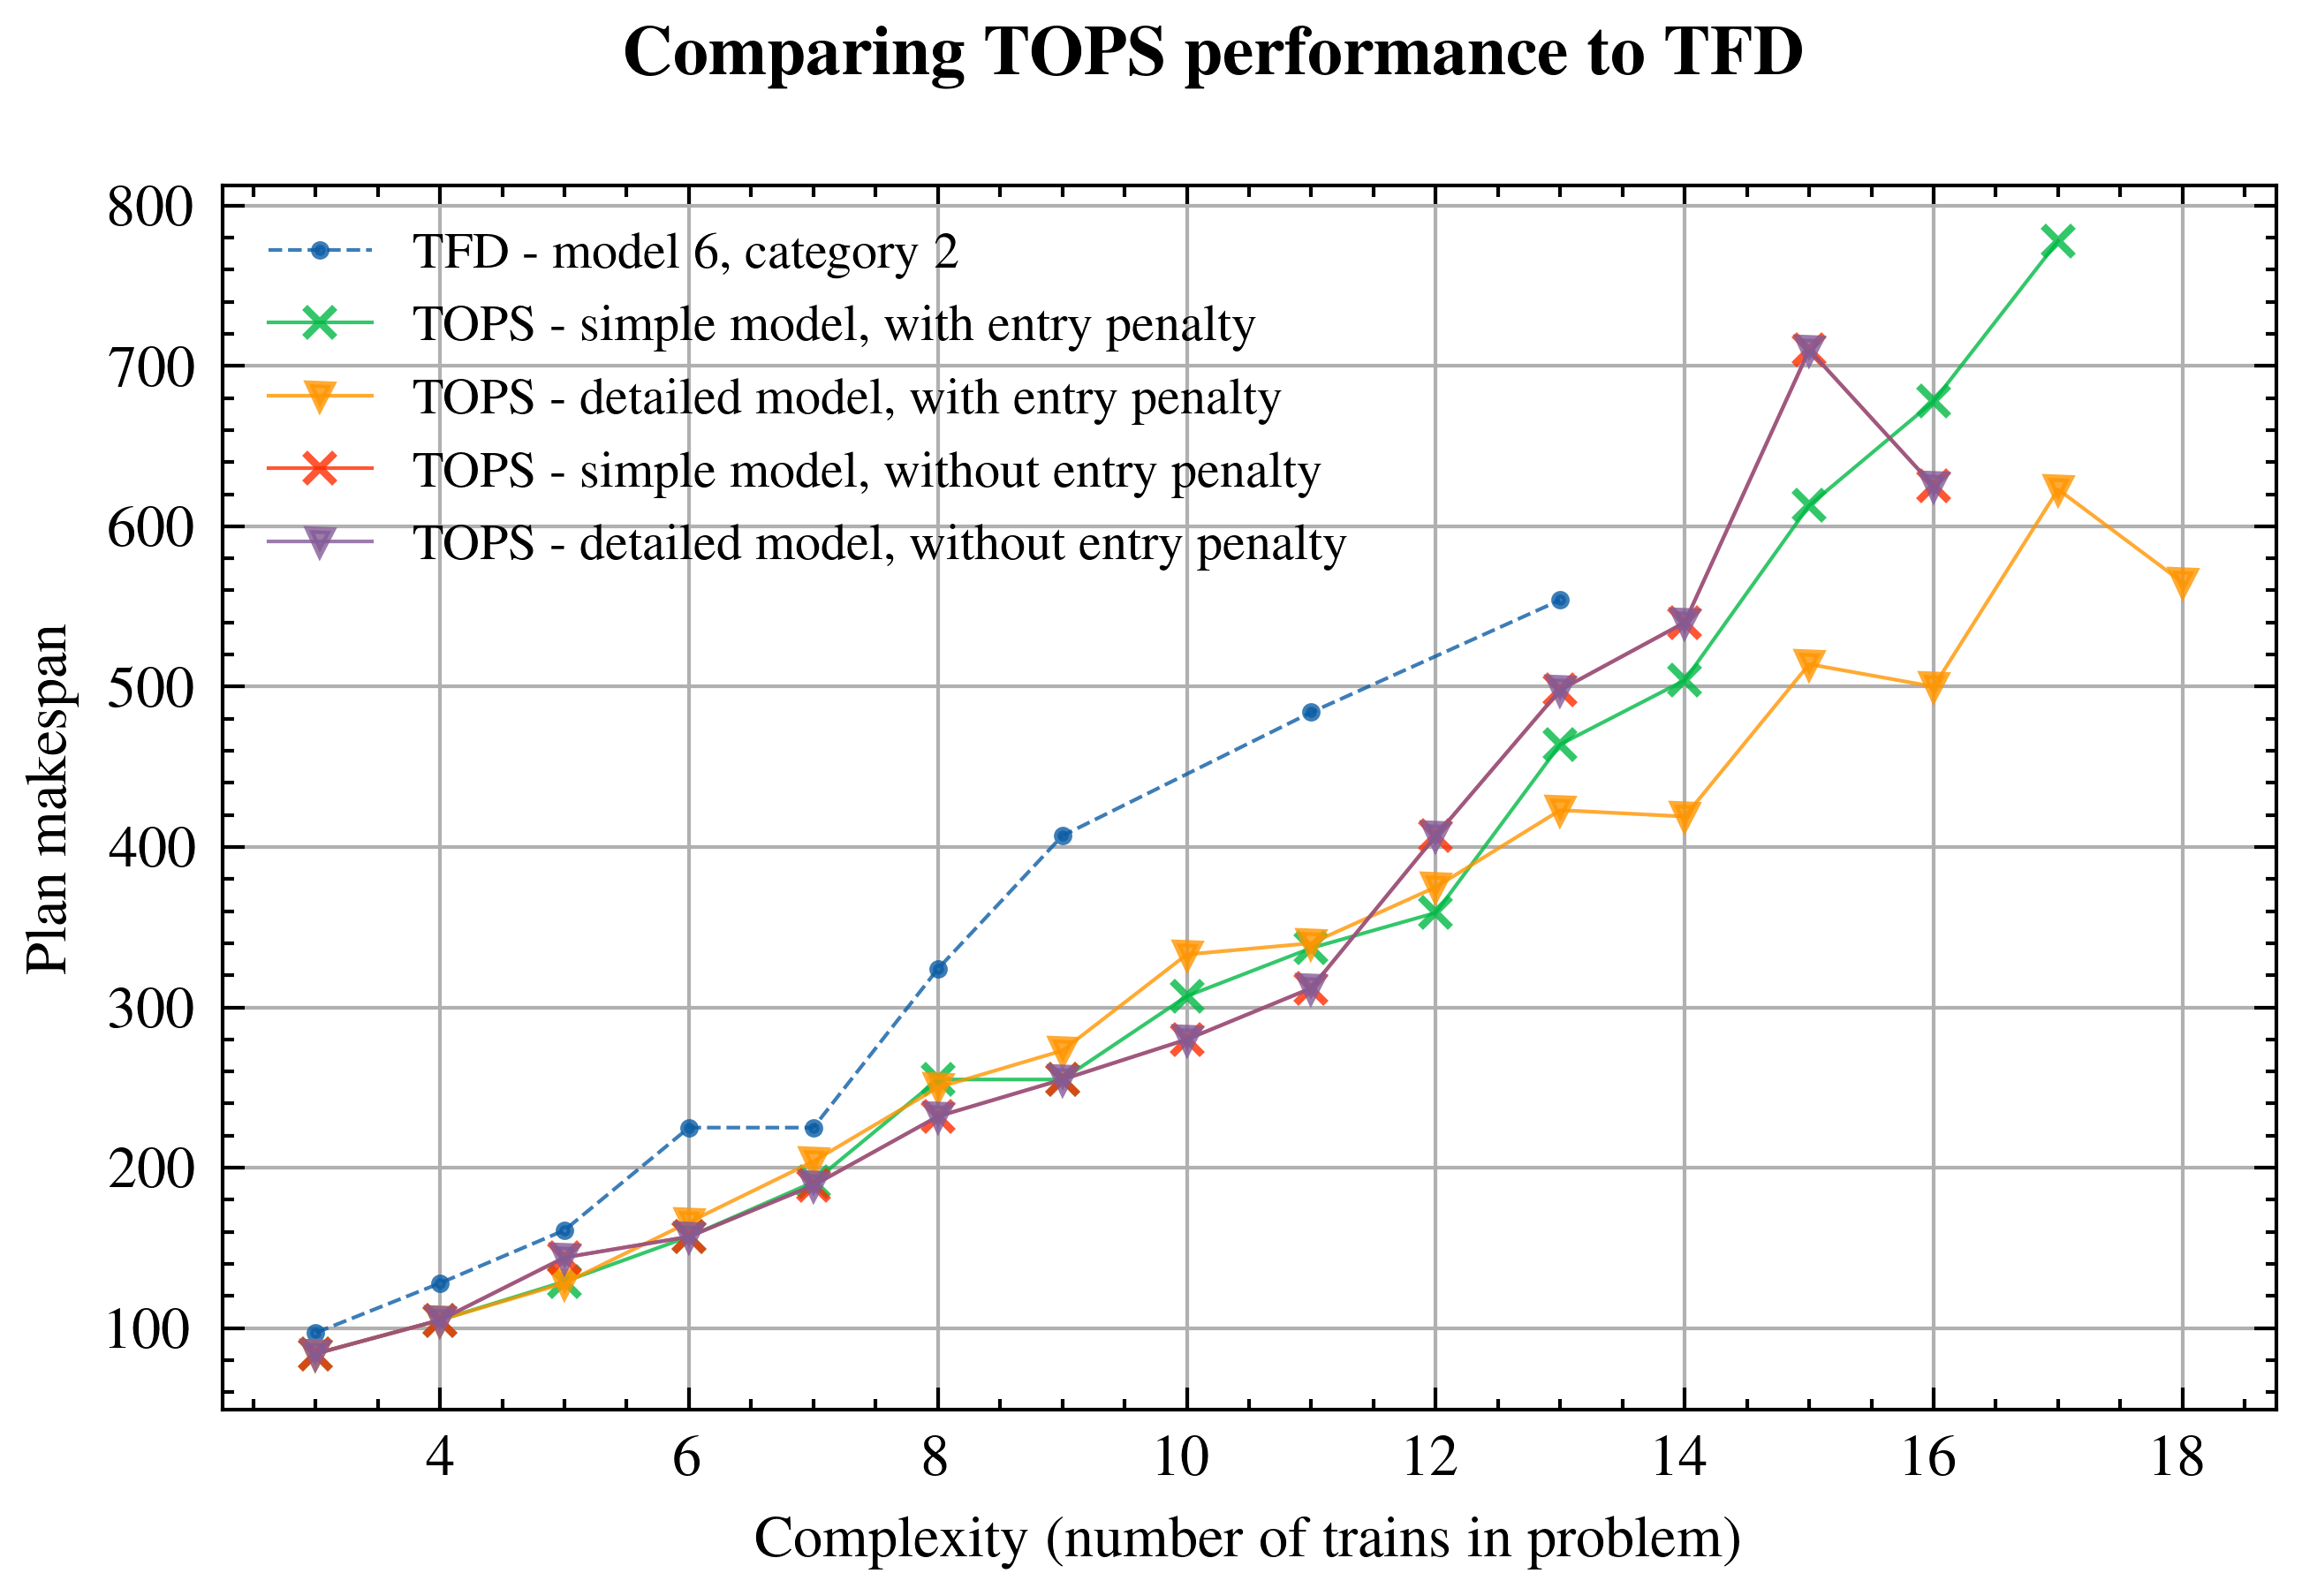

In [15]:
plt.style.use(['ieee', 'science'])

# x_tfd, y_tfd = [], []
# df_filt = df_tfd.query(f"config=={3}")
# # df_filt = df_filt[df_filt['makespan'] > 0]
# x_tfd  = list(df_filt['num_trains'])
# y_tfd = list(df_filt['makespan_pp'])

x_tfd2, y_tfd2 = [], []
df_filt = df_tfd.query(f"config=={16}")
# df_filt = df_filt[df_filt['makespan'] > 0]
x_tfd2  = list(df_filt['num_trains'])
y_tfd2 = list(df_filt['makespan_pp'])

x_tops, y_tops = [], []
df_filt = df.query(f"config=={30}")
# df_filt = df_filt[df_filt['makespan'] > 0]
x_tops = list(df_filt['num_trains'])
y_tops = list(df_filt['makespan_pp'])

x_tops2, y_tops2 = [], []
df_filt = df.query(f"config=={31}")
# df_filt = df_filt[df_filt['makespan'] > 0]
x_tops2 = list(df_filt['num_trains'])
y_tops2 = list(df_filt['makespan_pp'])

x_tops3, y_tops3 = [], []
df_filt = df.query(f"config=={40}")
# df_filt = df_filt[df_filt['makespan'] > 0]
x_tops3 = list(df_filt['num_trains'])
y_tops3 = list(df_filt['makespan_pp'])

x_tops4, y_tops4 = [], []
df_filt = df.query(f"config=={41}")
# df_filt = df_filt[df_filt['makespan'] > 0]
x_tops4 = list(df_filt['num_trains'])
y_tops4 = list(df_filt['makespan_pp'])


fig, ax = plt.subplots(1,1, figsize=(5,3), sharey=True, sharex=True)
# ax = ax.flatten()
fig.suptitle(r"""\textbf{Comparing TOPS performance to TFD}""")

# ax.plot(x_tfd, y_tfd, 'x--', label=f'TFD - config 1, base2', markersize=4)
ax.plot(x_tfd2, y_tfd2, '.--', label=f'TFD - model 6, category 2', markersize=3, linewidth=0.5, alpha=0.8)
ax.plot(x_tops, y_tops, 'x-', label=f'TOPS - simple model, with entry penalty', markersize=4, linewidth=0.5, alpha=0.8)
ax.plot(x_tops2, y_tops2, 'v-', label=f'TOPS - detailed model, with entry penalty', markersize=3, linewidth=0.5, alpha=0.8)
ax.plot(x_tops3, y_tops3, 'x-', label=f'TOPS - simple model, without entry penalty', markersize=4, linewidth=0.5, alpha=0.8)
ax.plot(x_tops3, y_tops3, 'v-', label=f'TOPS - detailed model, without entry penalty', markersize=3, linewidth=0.5, alpha=0.8)

ax.legend(loc='upper left', fontsize=7)
ax.grid(True)
# ax[i].set_xlabel('Number of trains in problem')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_ylabel('Plan makespan')
ax.set_xlabel('Complexity (number of trains in problem)')

# fig.tight_layout()
fig.savefig('tops_base3_makespans_pp.png')


In [5]:
y_tops2

[84, 105, 128, 166, 204, 250, 273, 333, 340, 375, 423, 419, 514, 500, 623, 565]

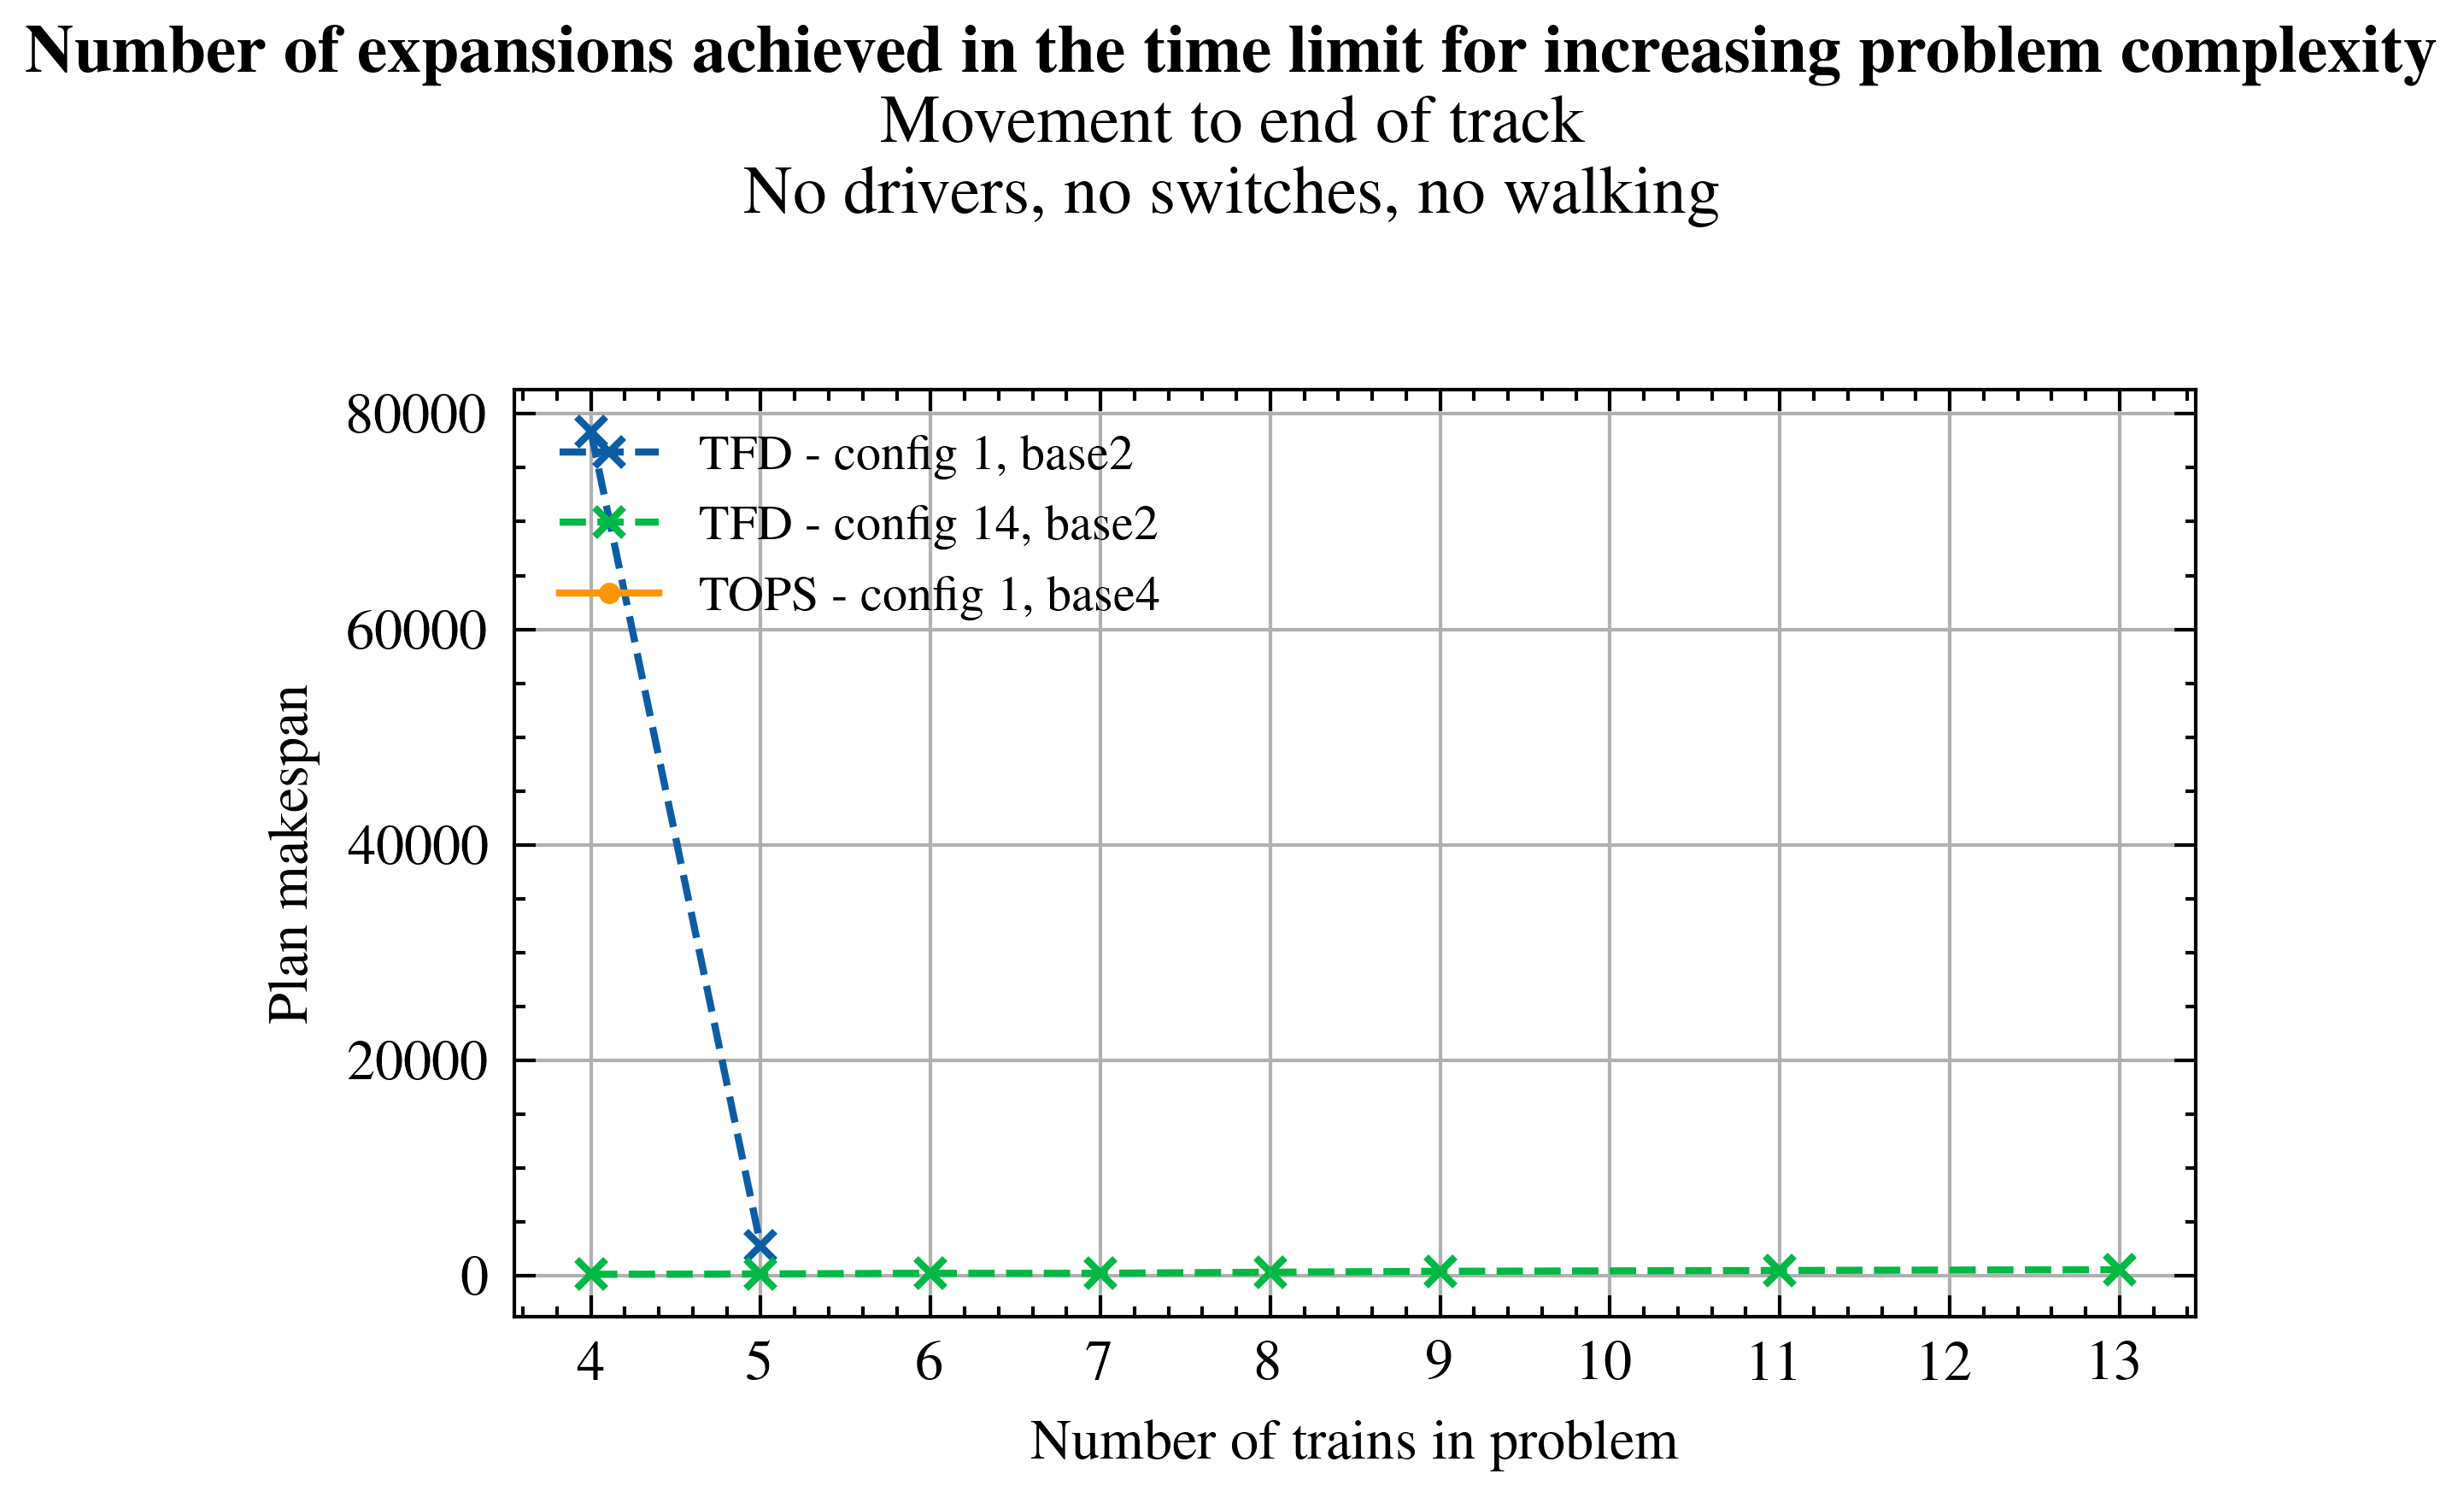

In [6]:
plt.style.use(['ieee', 'science'])


# x_enhsp, y_enhsp = [], []
# df_filt = df_enhsp.query(f"config=={1}")
# # df_filt = df_filt[df_filt['makespan'] > 0]
# x_enhsp  = list(df_filt['num_trains'])
# y_enhsp = list(df_filt['num_expansions'])

x_tfd, y_tfd = [], []
df_filt = df_tfd.query(f"config=={6}")
# df_filt = df_filt[df_filt['makespan'] > 0]
x_tfd  = list(df_filt['num_trains'])
y_tfd = list(df_filt['num_expansions'])

# x_tfd2, y_tfd2 = [], []
# df_filt = df_tfd.query(f"config=={14}")
# # df_filt = df_filt[df_filt['makespan'] > 0]
# x_tfd2  = list(df_filt['num_trains'])
# y_tfd2 = list(df_filt['num_expansions'])

x_tops, y_tops = [], []
df_filt = df.query(f"config=={1}")
# df_filt = df_filt[df_filt['makespan'] > 0]
x_tops = list(df_filt['num_trains'])
y_tops = list(df_filt['num_expansions'])

x_tops2, y_tops2 = [], []
df_filt = df.query(f"config=={10}")
# df_filt = df_filt[df_filt['makespan'] > 0]
x_tops2 = list(df_filt['num_trains'])
y_tops2 = list(df_filt['num_expansions'])


fig, ax = plt.subplots(1,1, figsize=(4,3), sharey=True, sharex=True)
# ax = ax.flatten()
fig.suptitle(r"""\textbf{Number of expansions achieved in the time limit for increasing problem complexity}
             Movement to end of track
             No drivers, no switches, no walking
            """)

# ax.plot(x_enhsp, y_enhsp, 'h--', label=f'ENHSP - config 1, base 4', markersize=4)
ax.plot(x_tfd[1:], y_tfd[1:], 'x--', label=f'TFD - config 1, base2', markersize=4)
ax.plot(x_tfd2[1:], y_tfd2[1:], 'x--', label=f'TFD - config 14, base2', markersize=4)
ax.plot(x_tops[1:], y_tops[1:], '.-', label=f'TOPS - config 1, base4', markersize=4)
# ax.plot(x_tops2, y_tops2, '.-', label=f'TOPS - config 2, base4', linewidth=1)

ax.legend(loc='upper left', fontsize=7)
ax.grid(True)
# ax[i].set_xlabel('Number of trains in problem')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_ylabel('Plan makespan')
ax.set_xlabel('Number of trains in problem')

fig.tight_layout()
fig.savefig('tops_base4_expansions.png')


In [7]:
plt.style.use(['ieee', 'science'])

x_tops = list(range(3,24))
